In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import numpy as np
from win_prob import *

In [3]:
df = pd.read_csv('Wimbledon_featured_matches.csv')

In [4]:
sets = df["p1_sets"].astype(str) + "-" + df["p2_sets"].astype(str)
games = df["p1_games"].astype(str) + "-" + df["p2_games"].astype(str)
points = df["p1_score"].astype(str) + "-" + df["p2_score"].astype(str)
server = df["server"]
p = 0.655161325 
met = Metric_Finder(p)
df["win_prob"] = list(map(lambda x,y,z: win_prob(x,y,z), sets, games, points))
df["aheadness"] = list(map(lambda x,y,z,a: met.find_metric(x, y, z, a), sets, games, points, server))

In [5]:
# cleaning
df['elapsed_time'] = pd.to_timedelta(df['elapsed_time'])
df['elapsed_time'] = df['elapsed_time'].dt.total_seconds()

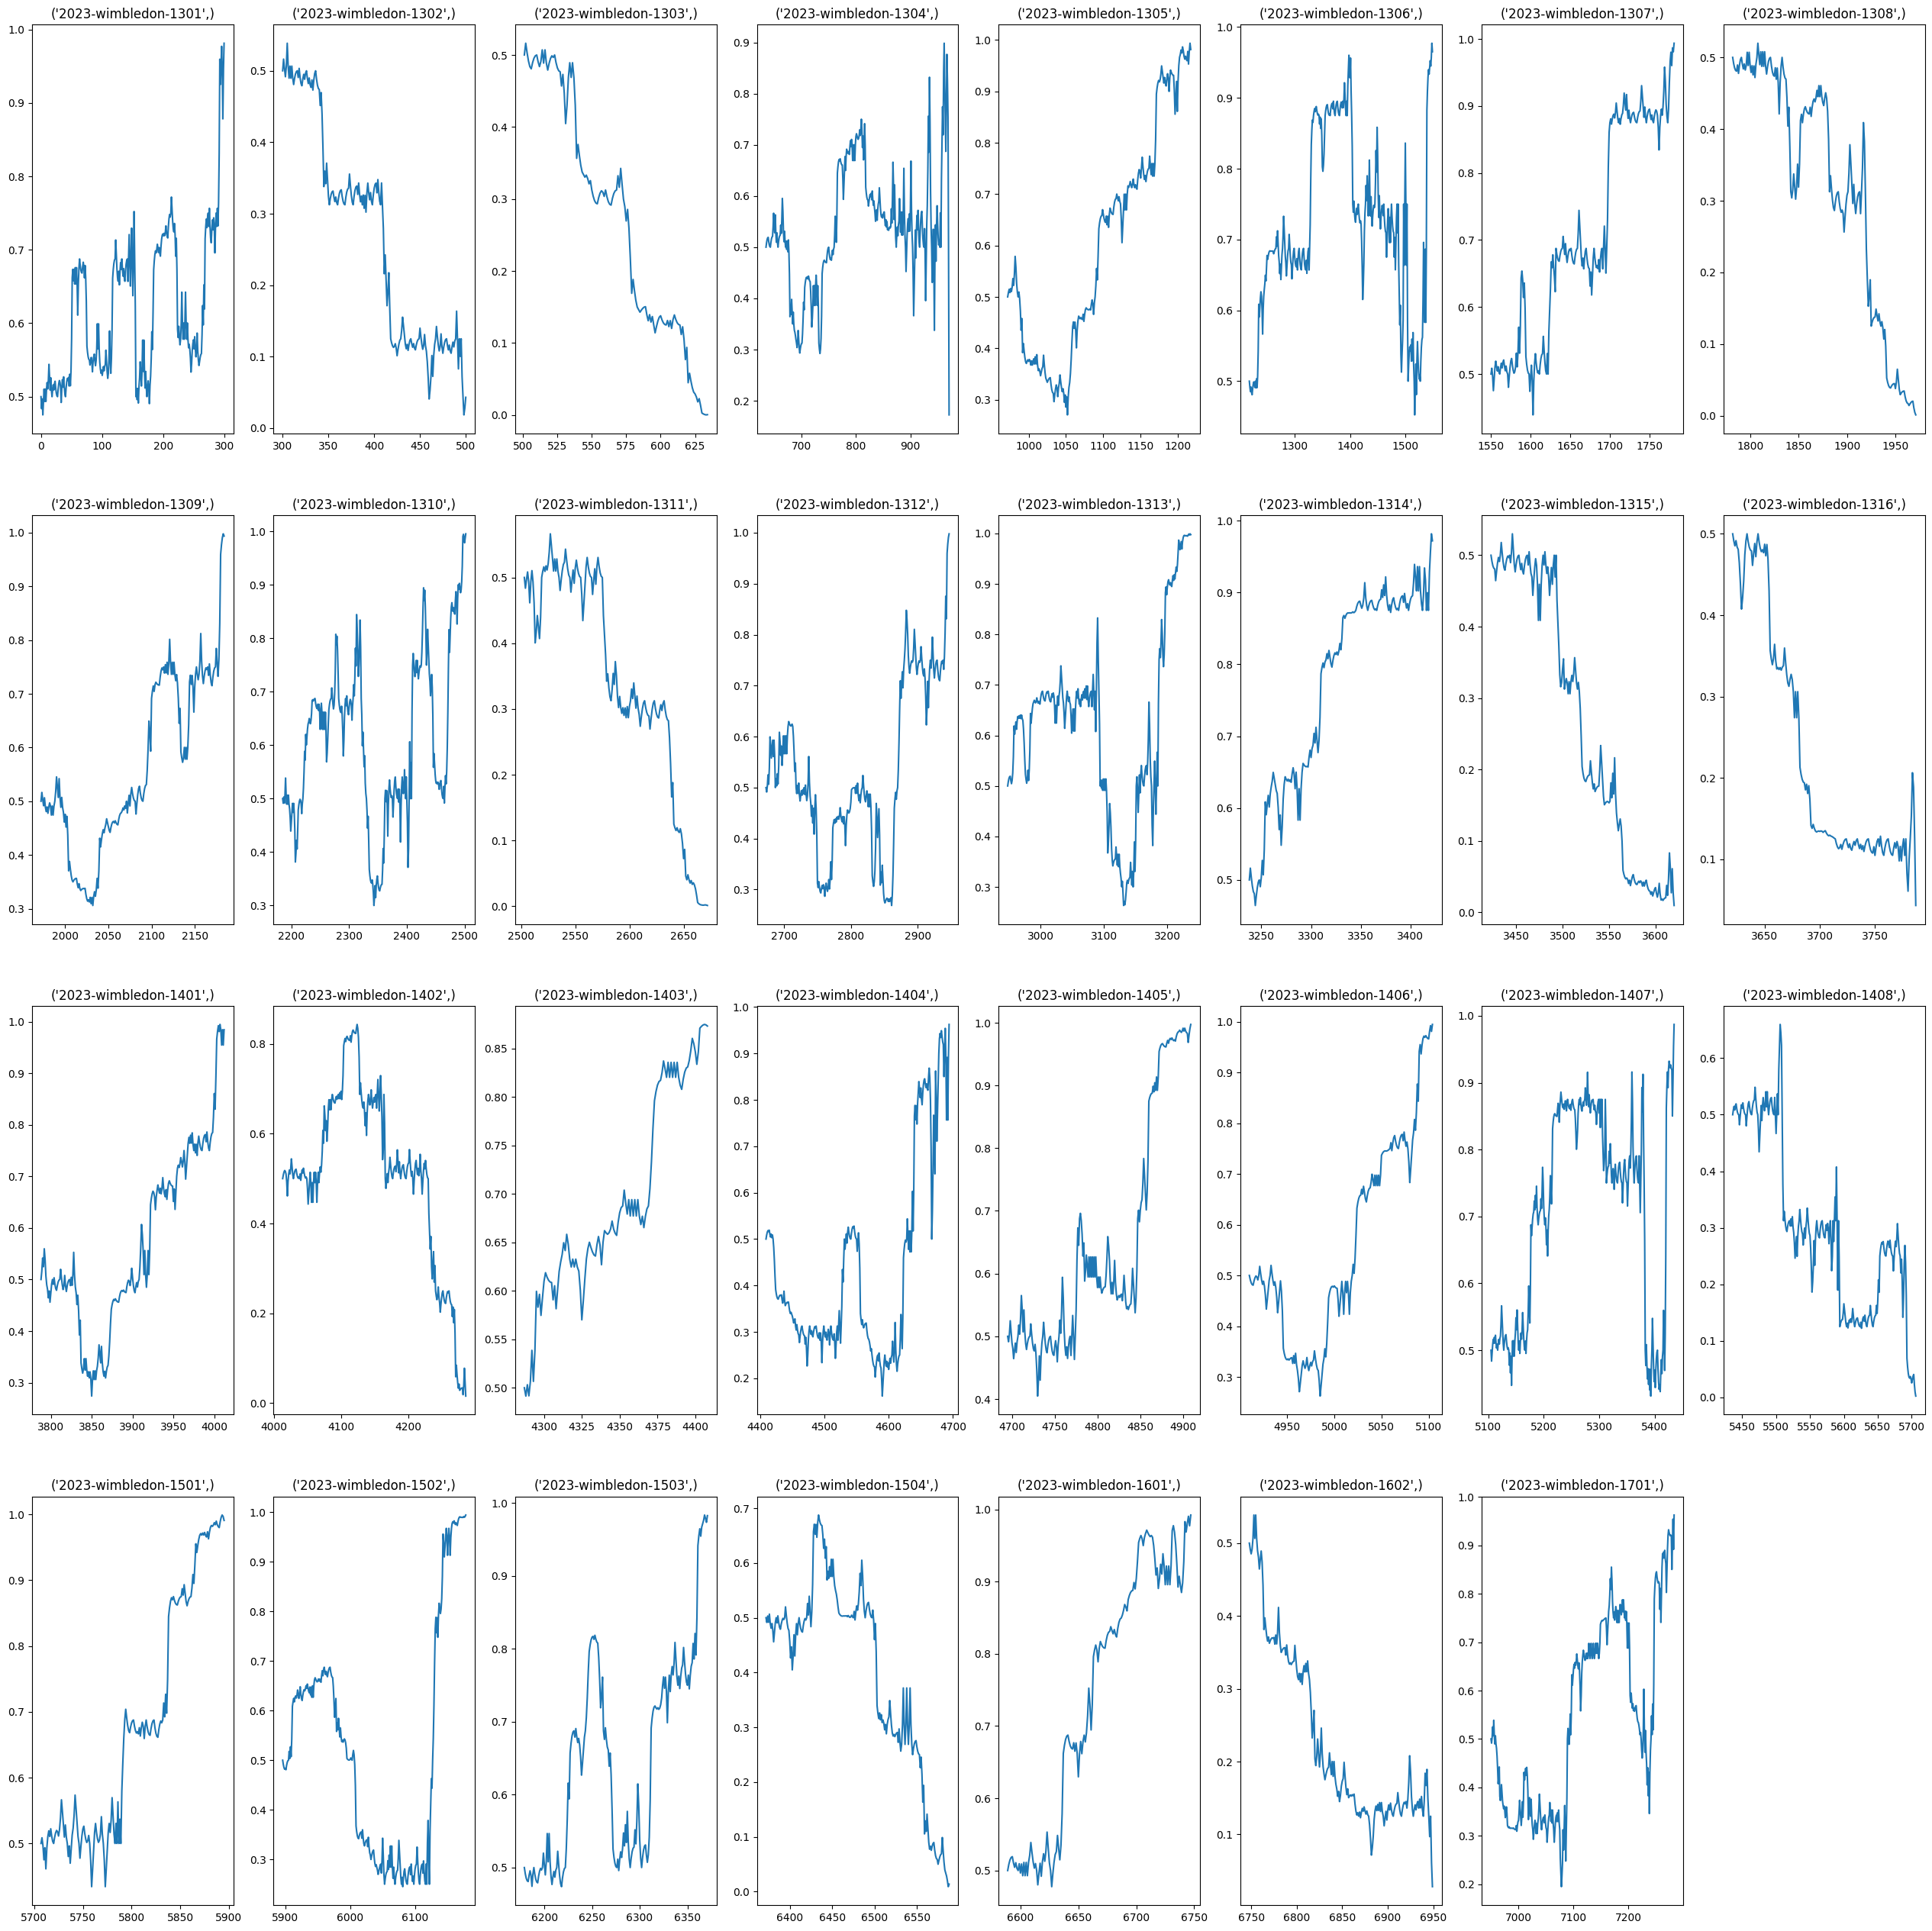

In [6]:
plt.figure(figsize=(32,32))
i = 0
for name, group in df.groupby(['match_id']):
    i += 1
    plt.subplot(4, 8, i)
    plt.plot(group.index, group['aheadness'])
    plt.title(name)

In [27]:
# add derivatives to df
df['win_prob_dev'] = 0.0
for i in range(len(df)):
    if df.loc[i, 'point_no'] == 1:
        df.loc[i, 'win_prob_dev'] = 0
    else:
        df.loc[i, 'win_prob_dev'] = df.loc[i, 'win_prob'] - df.loc[i-1, 'win_prob']

df['aheadness_dev'] = 0.0
for i in range(len(df)):
    if df.loc[i, 'point_no'] == 1:
        df.loc[i, 'aheadness_dev'] = 0
    else:
        df.loc[i, 'aheadness_dev'] = df.loc[i, 'aheadness'] - df.loc[i-1, 'aheadness']

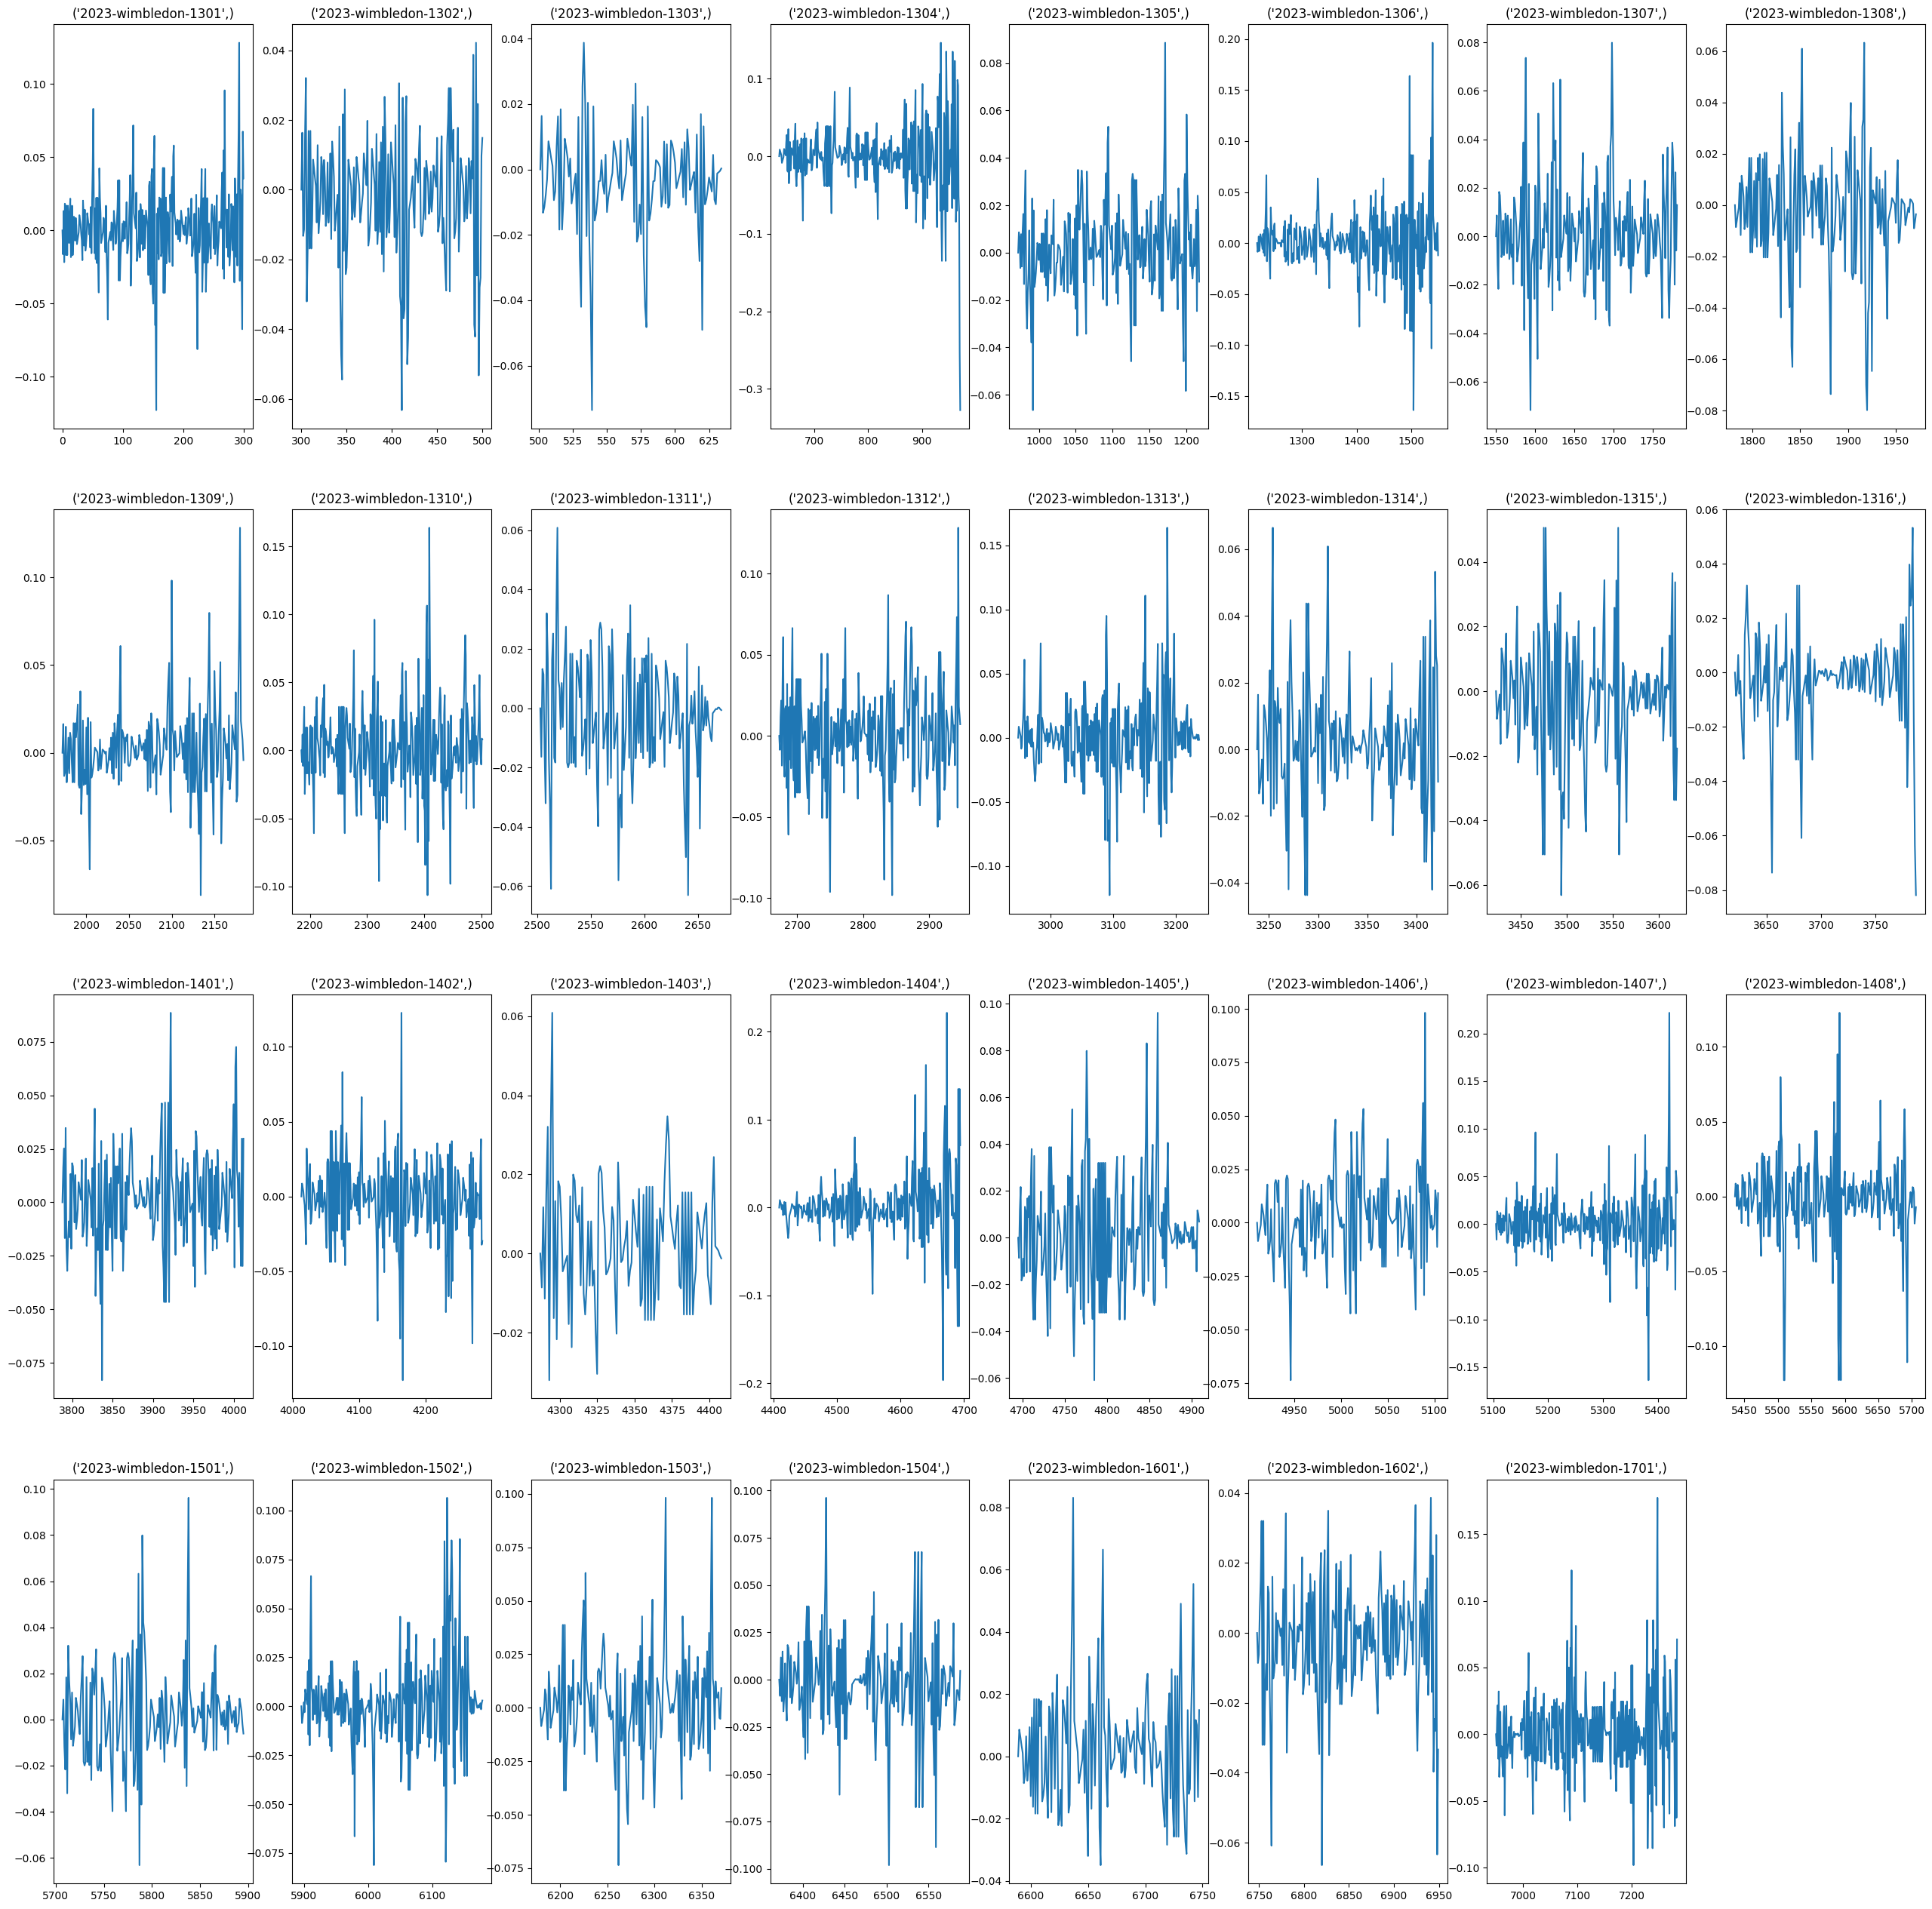

In [31]:
plt.figure(figsize=(32,32))
i = 0
for name, group in df.groupby(['match_id']):
    i += 1
    plt.subplot(4, 8, i)
    plt.plot(group.index, group['aheadness_dev'])
    plt.title(name)

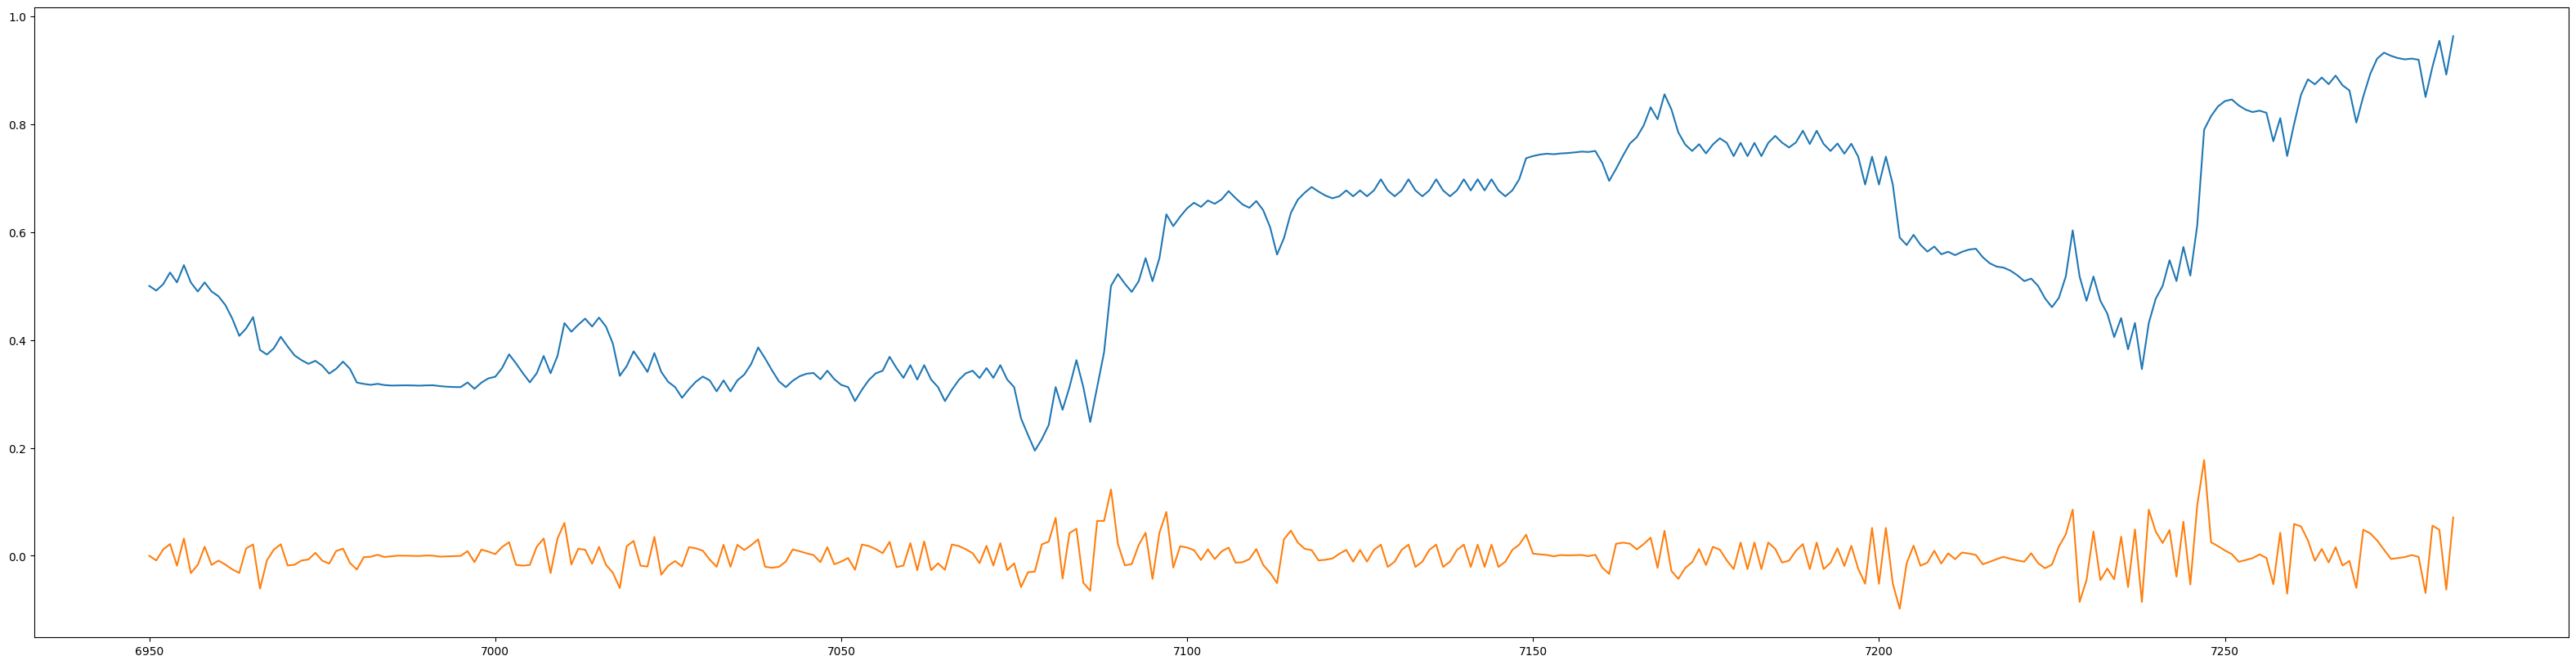

In [42]:
plt.figure(figsize=(40,10))
plt.plot(df[df['match_id'] == '2023-wimbledon-1701']['aheadness'])
plt.plot(df[df['match_id'] == '2023-wimbledon-1701']['aheadness_dev'])

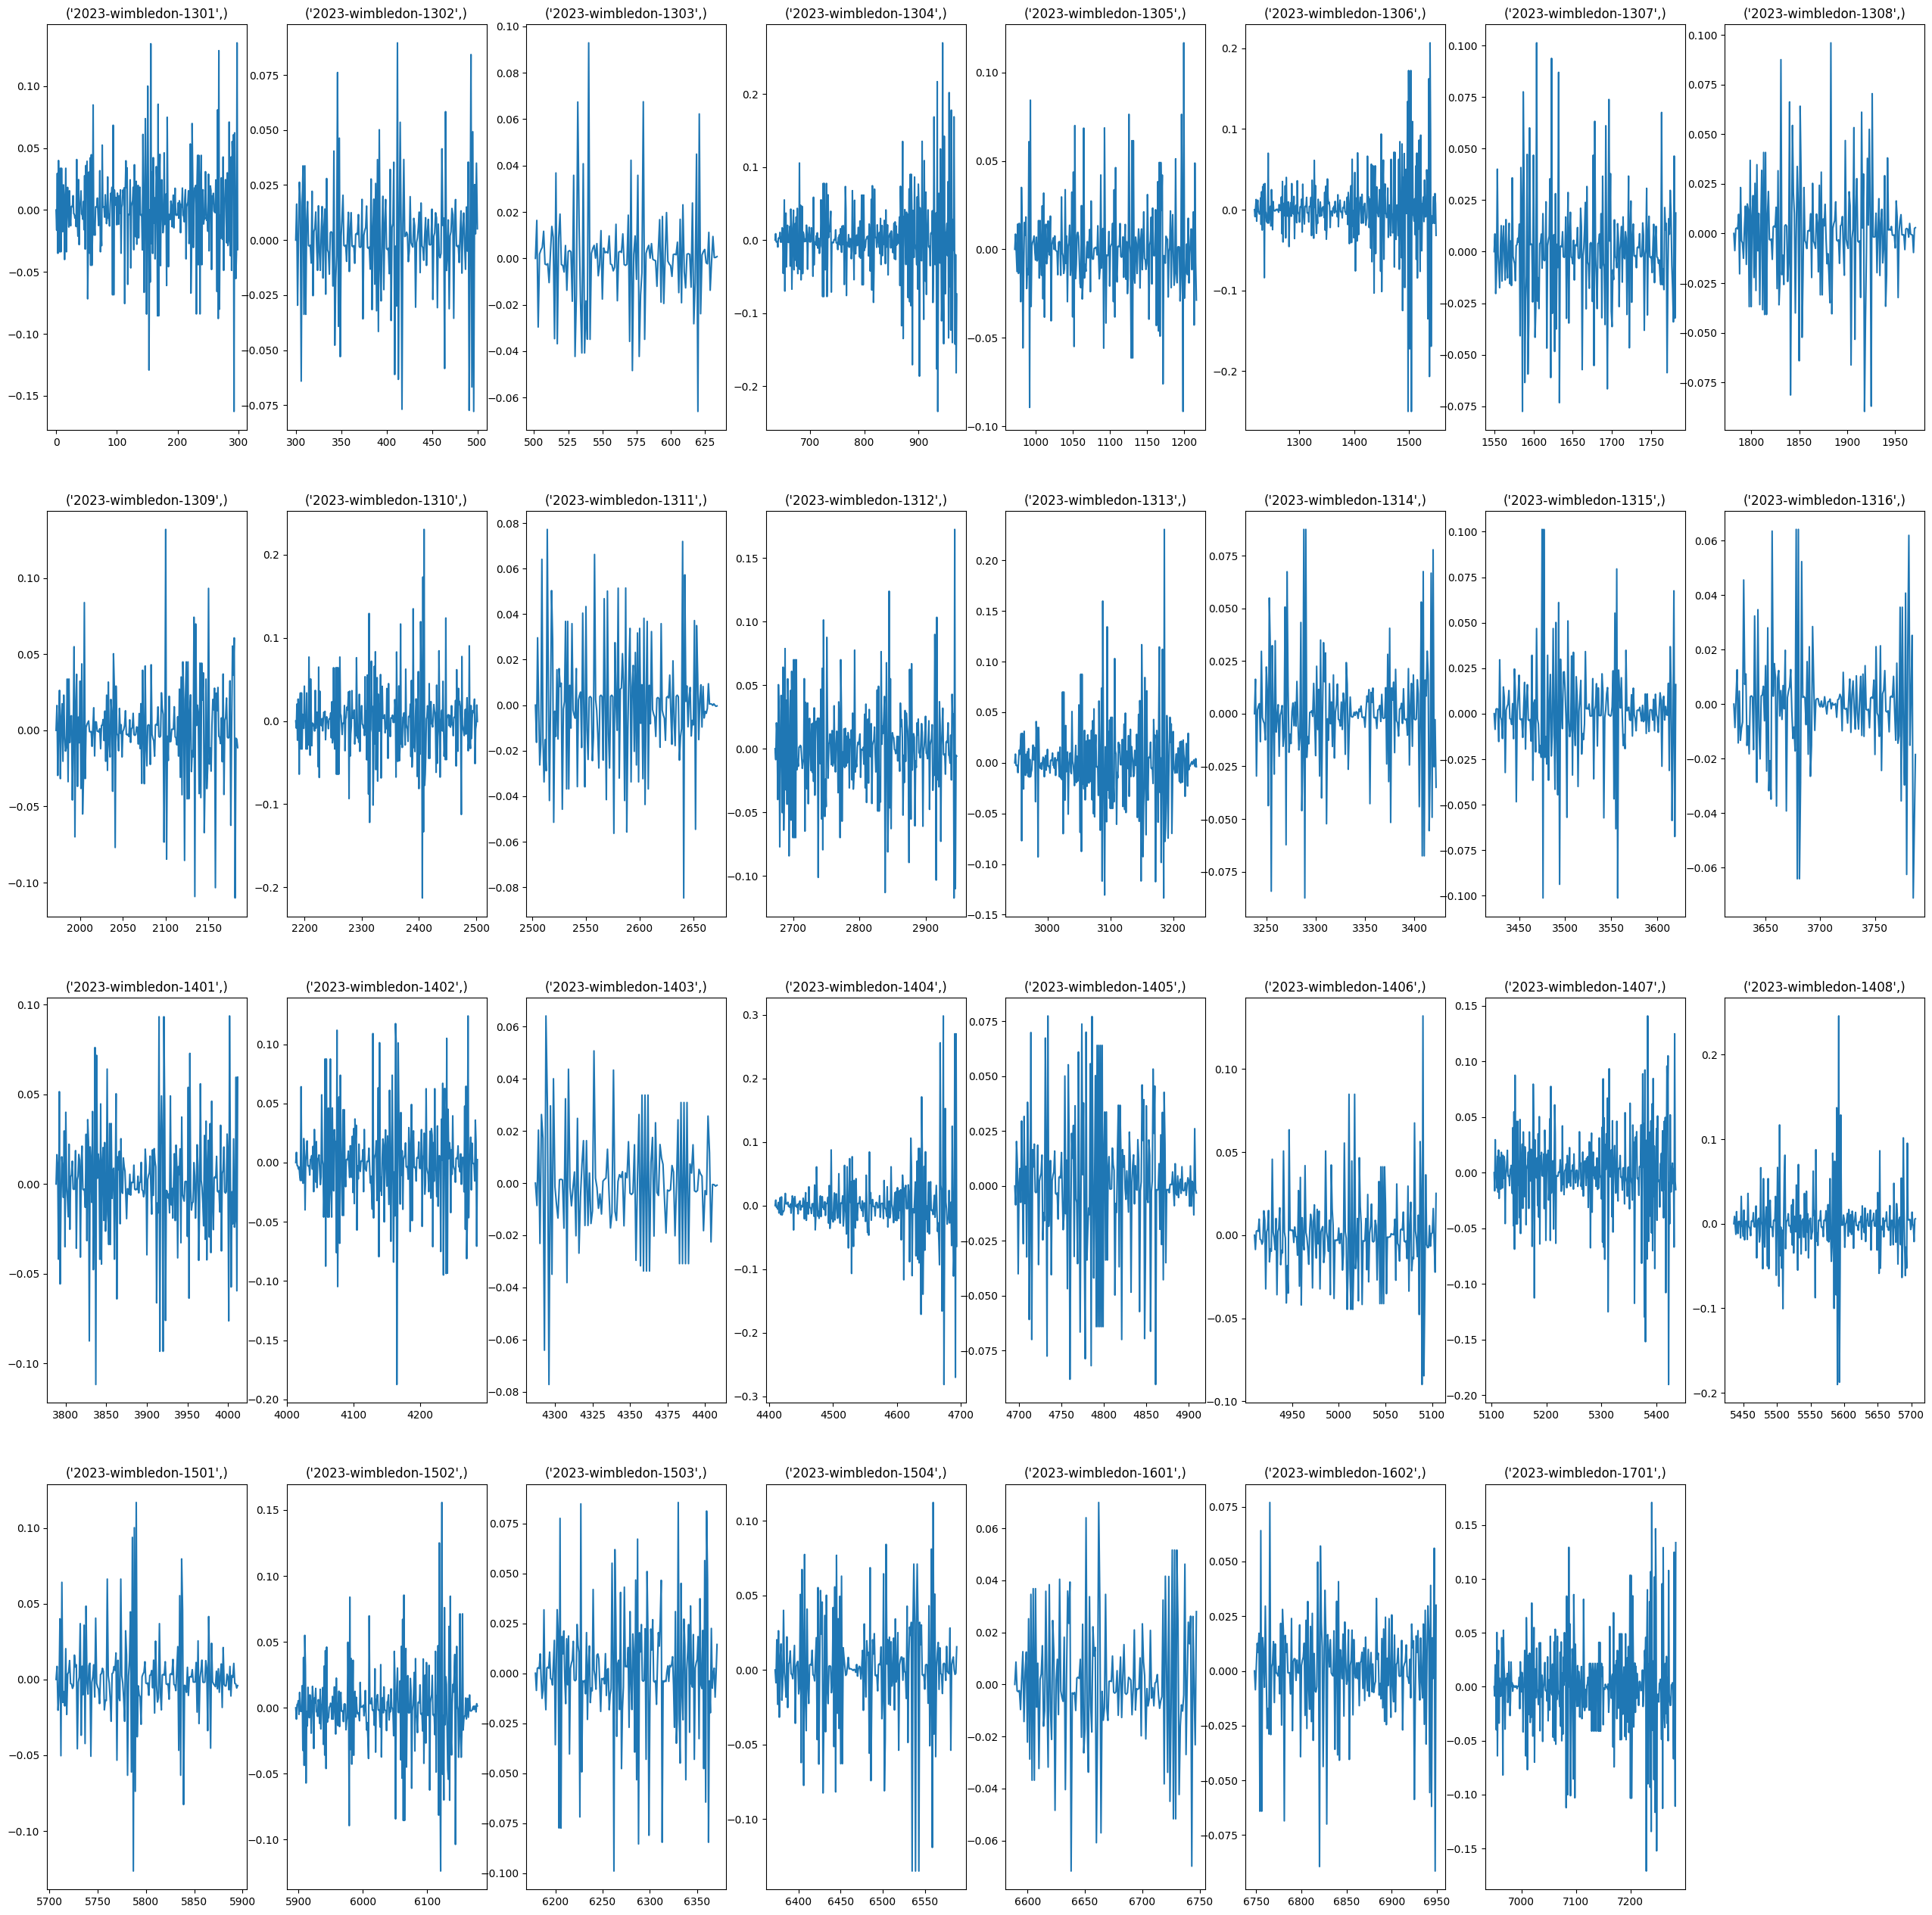

In [32]:
# plot of second derivative
plt.figure(figsize=(32,32))
i = 0
for name, group in df.groupby(['match_id']):
    i += 1
    plt.subplot(4, 8, i)
    plt.plot(group.index, np.insert(np.diff(group['aheadness_dev']), 0, 0))
    plt.title(name)